In [ ]:
import zipfile, os
from google.colab import files

# Step 1: Upload dataset ZIP
uploaded = files.upload()

# Step 2: Extract dataset
for fname in uploaded.keys():
    with zipfile.ZipFile(fname, 'r') as zip_ref:
        zip_ref.extractall("/content/Brain_MRI_Dataset")
DATA_DIR = "/content/Brain_MRI_Dataset"

print("Dataset extracted to:", DATA_DIR)
print("Classes:", os.listdir(DATA_DIR))


Saving archive (2).zip to archive (2).zip
Dataset extracted to: /content/Brain_MRI_Dataset
Classes: ['Training', 'Testing']


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification (EfficientNetB3)
# MixUp disabled for small dataset
# Target: ~99% Accuracy
# ============================================================

import os, random, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras import layers, models, callbacks, applications, optimizers
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# CONFIG
# -----------------------------
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Dataset Paths
ARCHIVE_PATH = "/content/archive.zip"  # uploaded file
EXTRACT_TO = "/content/Brain_MRI_Dataset"
DATA_DIR = os.path.join(EXTRACT_TO, "Training")

# Model/Training Config
IMG_SIZE = (300, 300)
BATCH_SIZE = 8
NUM_CLASSES = 4
EPOCHS = 50
INITIAL_FREEZE_EPOCHS = 6
AUTOTUNE = tf.data.AUTOTUNE
USE_MIXUP = False   # ❌ disabled for small dataset

# -----------------------------
# EXTRACT DATASET
# -----------------------------
if not os.path.exists(EXTRACT_TO):
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as zf:
        zf.extractall("/content")
print("✅ Dataset extracted to:", EXTRACT_TO)
print("Subfolders:", os.listdir(EXTRACT_TO))

# -----------------------------
# PREPROCESSING FUNCTIONS
# -----------------------------
def autocrop_and_resize(img, out_size=IMG_SIZE):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return cv2.resize(img, out_size)
    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    crop = img[y:y+h, x:x+w]
    crop = cv2.resize(crop, out_size)
    return crop

def preprocessing_function(img):
    arr = np.uint8(img)
    arr = autocrop_and_resize(arr, out_size=IMG_SIZE)
    yuv = cv2.cvtColor(arr, cv2.COLOR_RGB2YUV)
    yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])
    out = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
    return out.astype(np.float32) / 255.0

# -----------------------------
# DATA LOADING PIPELINE
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Normalize + cache + prefetch
def preprocess(x, y):
    x = tf.image.convert_image_dtype(x, tf.float32)
    return x, y

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# -----------------------------
# MODEL: EfficientNetB3
# -----------------------------
def build_efficientnetb3(num_classes=NUM_CLASSES, dropout=0.4):
    base = applications.EfficientNetB3(
        weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3)
    )
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(base.input, out)
    return model

model = build_efficientnetb3()

# -----------------------------
# CALLBACKS
# -----------------------------
cb_list = [
    callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.TensorBoard(log_dir="logs/efficientnet")
]

# -----------------------------
# TRAINING PHASE 1 (Frozen Base)
# -----------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Starting Phase 1 Training (Frozen Base)...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_FREEZE_EPOCHS,
    callbacks=cb_list
)

# -----------------------------
# PHASE 2 (Fine-tuning)
# -----------------------------
# Unfreeze top 30 layers for fine-tuning
for layer in model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Starting Phase 2 Training (Fine-tuning)...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=history1.epoch[-1] + 1 if history1.epoch else 0,
    callbacks=cb_list
)

# -----------------------------
# EVALUATION
# -----------------------------
print("\n✅ Loading Best Model...")
model.load_weights("best_model.keras")

val_images, val_labels = [], []
for imgs, lbls in val_ds.unbatch().take(500):
    val_images.append(imgs)
    val_labels.append(lbls)
val_images = tf.stack(val_images)
val_labels = tf.stack(val_labels)

preds = model.predict(val_images)
pred_classes = tf.argmax(preds, axis=1)

print("\n📊 Classification Report:")
print(classification_report(val_labels, pred_classes))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(val_labels, pred_classes))

✅ Dataset extracted to: /content/Brain_MRI_Dataset
Subfolders: ['Training', 'Testing']
Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting Phase 1 Training (Frozen Base)...
Epoch 1/6
572/572 ━━━━━━━━━━━━━━━━━━━━ 124s 140ms/step - accuracy: 0.7032 - loss: 0.7600 - val_accuracy: 0.8958 - val_loss: 0.3055 - learning_rate: 1.0000e-04
Epoch 2/6
572/572 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0.8648 - loss: 0.3618 - val_accuracy: 0.9186 - val_loss: 0.2425 - learning_rate: 1.0000e-04
Epoch 3/6
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.8920 - loss: 0.3003 - val_accuracy: 0.9159 - val_loss: 0.2227 - learning_rate: 1.0000e-04
Epoch 4/6
572/572 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.8955 - loss: 0.2780 - val_accuracy: 0.9361 - val_loss: 0.1975 - learning_rate: 1.0000e-04
Epoch 5/6
572/572 ━━━━━━━━━━━━━━━━━━━━ 39


🧩 Confusion Matrix:
[[102   2   0   0]
 [  4 110   2   2]
 [  0   1 142   0]
 [  0   1   0 134]]

📈 Sensitivity (Recall) and Specificity per Class:
Class_0         → Sensitivity: 0.9808,  Specificity: 0.9899
Class_1         → Sensitivity: 0.9322,  Specificity: 0.9895
Class_2         → Sensitivity: 0.9930,  Specificity: 0.9944
Class_3         → Sensitivity: 0.9926,  Specificity: 0.9945

📊 Overall Averages:
Mean Sensitivity : 0.9746
Mean Specificity : 0.9921


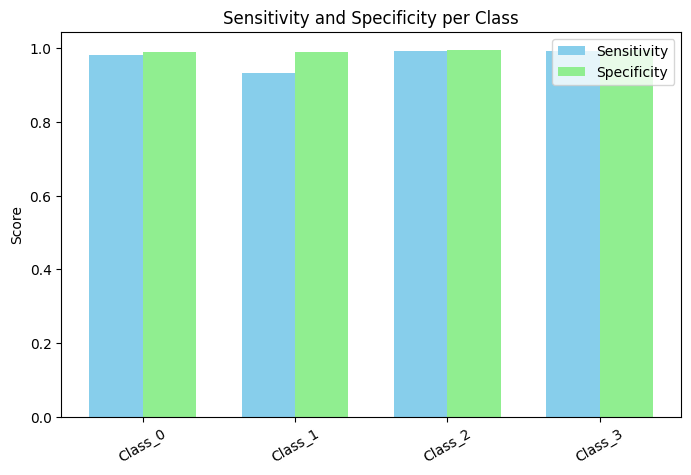

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# --- Confusion Matrix ---
cm = confusion_matrix(val_labels, pred_classes)
print("\n🧩 Confusion Matrix:")
print(cm)

# --- Sensitivity & Specificity Calculation ---
num_classes = cm.shape[0]
sensitivity = []
specificity = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

# --- Display Results ---
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else val_ds.class_names if hasattr(val_ds, 'class_names') else ['Class_0', 'Class_1', 'Class_2', 'Class_3']


print("\n📈 Sensitivity (Recall) and Specificity per Class:")
for i, cls in enumerate(class_names):
    print(f"{cls:15s} → Sensitivity: {sensitivity[i]:.4f},  Specificity: {specificity[i]:.4f}")

# --- Mean metrics ---
print("\n📊 Overall Averages:")
print(f"Mean Sensitivity : {np.mean(sensitivity):.4f}")
print(f"Mean Specificity : {np.mean(specificity):.4f}")

import matplotlib.pyplot as plt

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, sensitivity, width, label='Sensitivity', color='skyblue')
plt.bar(x + width/2, specificity, width, label='Specificity', color='lightgreen')
plt.xticks(x, class_names, rotation=30)
plt.ylabel("Score")
plt.title("Sensitivity and Specificity per Class")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


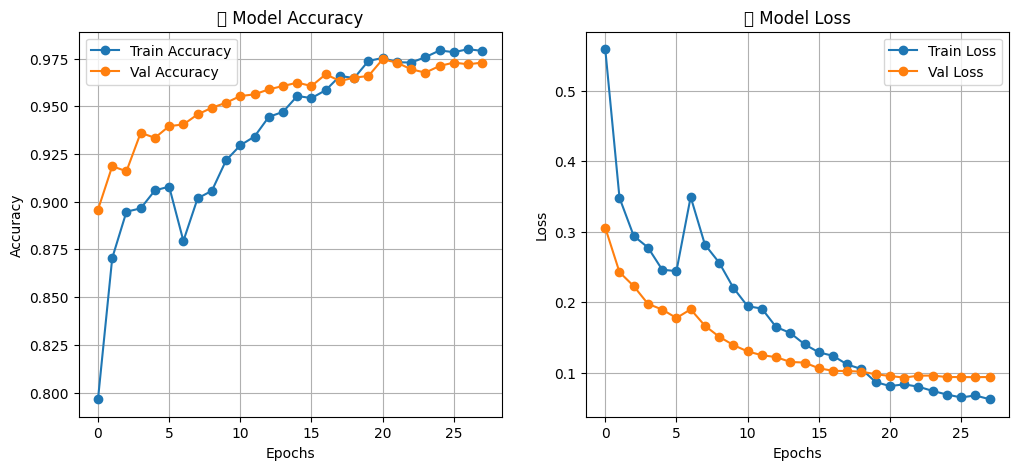

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


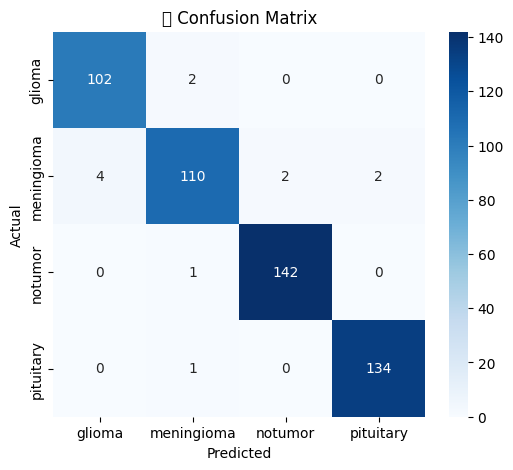

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


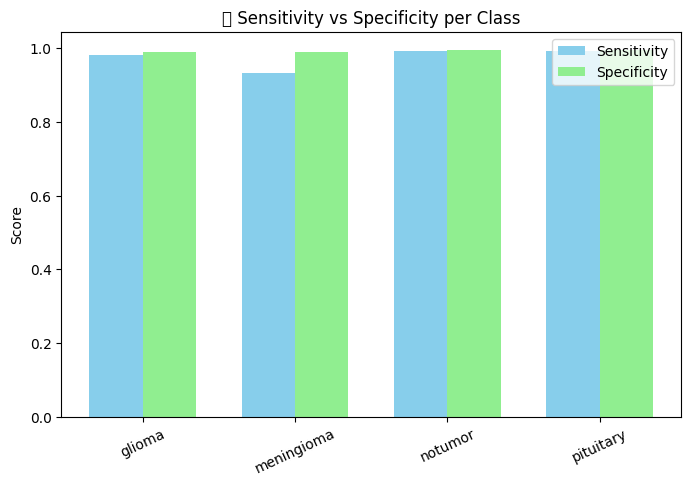

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


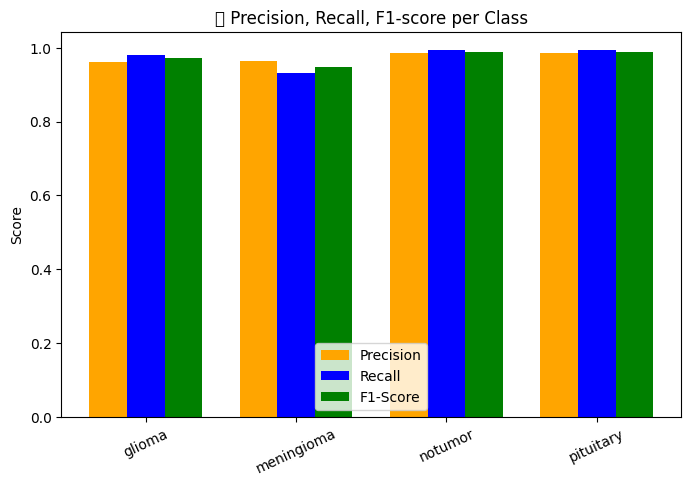

/tmp/ipython-input-4044220603.py:124: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


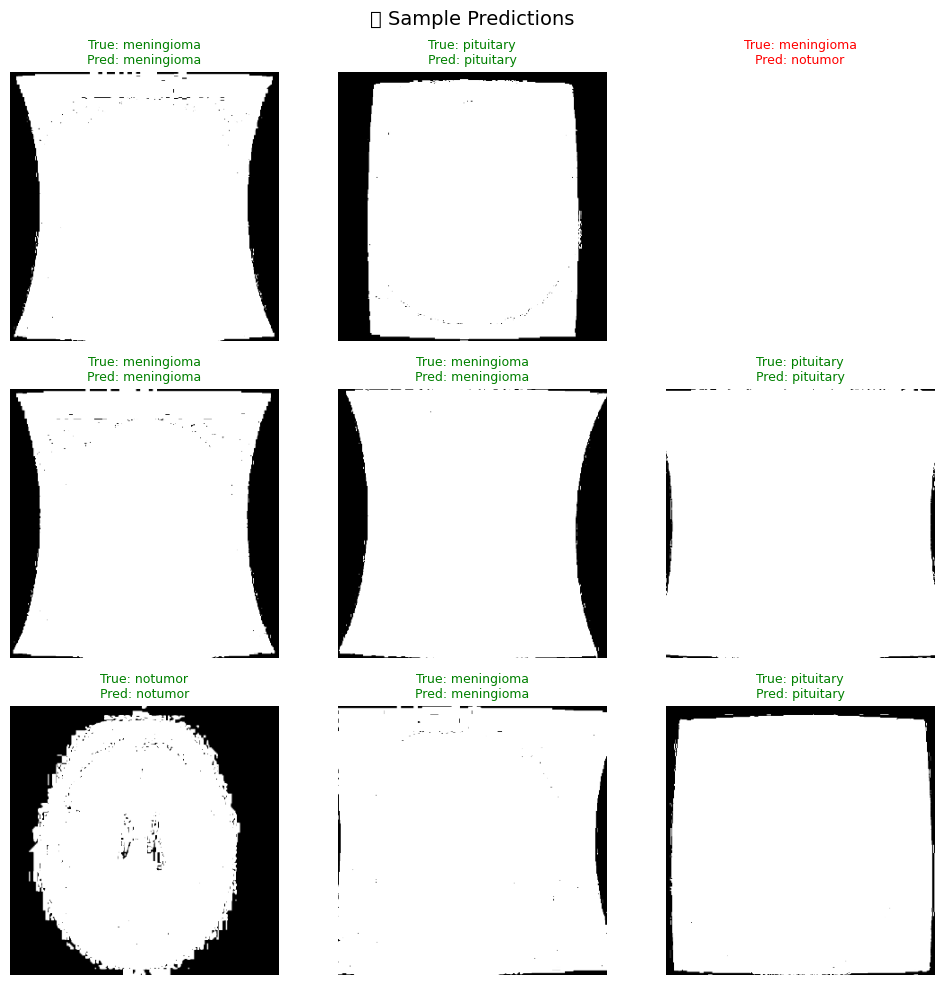


✅ Overall Accuracy: 97.60%
📊 Mean Sensitivity: 0.9746
📊 Mean Specificity: 0.9921
🎯 Mean Precision: 0.9746
🎯 Mean Recall: 0.9746
🎯 Mean F1-Score: 0.9745


In [ ]:
# ============================================================
# 📊 VISUALIZATION SECTION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# -----------------------------
# 1️⃣ Combine Training Histories (Phase 1 + Phase 2)
# -----------------------------
def combine_histories(h1, h2):
    hist = {}
    for key in h1.history.keys():
        hist[key] = h1.history[key] + h2.history.get(key, [])
    return hist

history = combine_histories(history1, history2)

# -----------------------------
# 2️⃣ Plot Training Curves
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('📈 Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history['loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('📉 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 3️⃣ Confusion Matrix Heatmap
# -----------------------------
cm = confusion_matrix(val_labels, pred_classes)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # <-- modify if your folder names differ

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("🧩 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 4️⃣ Sensitivity & Specificity
# -----------------------------
num_classes = cm.shape[0]
sensitivity, specificity = [], []

for i in range(num_classes):
    TP = cm[i,i]
    FN = np.sum(cm[i,:]) - TP
    FP = np.sum(cm[:,i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    sensitivity.append(sens)
    specificity.append(spec)

plt.figure(figsize=(8,5))
x = np.arange(len(class_names))
width = 0.35
plt.bar(x - width/2, sensitivity, width, label='Sensitivity', color='skyblue')
plt.bar(x + width/2, specificity, width, label='Specificity', color='lightgreen')
plt.xticks(x, class_names, rotation=25)
plt.ylabel("Score")
plt.title("📊 Sensitivity vs Specificity per Class")
plt.legend()
plt.show()

# -----------------------------
# 5️⃣ Precision, Recall, F1-score Visualization
# -----------------------------
precision = precision_score(val_labels, pred_classes, average=None)
recall = recall_score(val_labels, pred_classes, average=None)
f1 = f1_score(val_labels, pred_classes, average=None)

plt.figure(figsize=(8,5))
bar_width = 0.25
r1 = np.arange(len(class_names))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

plt.bar(r1, precision, width=bar_width, label='Precision', color='orange')
plt.bar(r2, recall, width=bar_width, label='Recall', color='blue')
plt.bar(r3, f1, width=bar_width, label='F1-Score', color='green')

plt.xticks([r + bar_width for r in range(len(class_names))], class_names, rotation=25)
plt.ylabel("Score")
plt.title("🎯 Precision, Recall, F1-score per Class")
plt.legend()
plt.show()

# -----------------------------
# 6️⃣ Sample Predictions Visualization
# -----------------------------
import random

plt.figure(figsize=(10,10))
for i in range(9):
    idx = random.randint(0, len(val_images)-1)
    img = val_images[idx]
    true_label = class_names[val_labels[idx]]
    pred_label = class_names[pred_classes[idx]]
    color = "green" if true_label == pred_label else "red"
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("🧠 Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------
# 7️⃣ Overall Summary Metrics
# -----------------------------
overall_acc = accuracy_score(val_labels, pred_classes)
print(f"\n✅ Overall Accuracy: {overall_acc*100:.2f}%")
print(f"📊 Mean Sensitivity: {np.mean(sensitivity):.4f}")
print(f"📊 Mean Specificity: {np.mean(specificity):.4f}")
print(f"🎯 Mean Precision: {np.mean(precision):.4f}")
print(f"🎯 Mean Recall: {np.mean(recall):.4f}")
print(f"🎯 Mean F1-Score: {np.mean(f1):.4f}")


In [ ]:
# -----------------------------
# EVALUATION
# -----------------------------
print("\n✅ Loading Best Model...")
model.load_weights("best_model.keras")

val_images, val_labels = [], []
for imgs, lbls in val_ds.unbatch().take(500):
    val_images.append(imgs)
    val_labels.append(lbls)
val_images = tf.stack(val_images)
val_labels = tf.stack(val_labels)

preds = model.predict(val_images)
pred_classes = tf.argmax(preds, axis=1)

# ✅ Print accuracy
accuracy = np.mean(pred_classes.numpy() == val_labels.numpy())
print(f"\n🎯 Validation Accuracy: {accuracy * 100:.2f}%")

# 📊 Reports
print("\n📊 Classification Report:")
print(classification_report(val_labels, pred_classes))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(val_labels, pred_classes))

# 🧠 Heuristic score (optional, if you included it)
score = heuristic_score(val_labels.numpy(), preds)
print(f"\n💡 Heuristic Score: {score:.4f}")



✅ Loading Best Model...
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step

🎯 Validation Accuracy: 98.20%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       102
           1       0.97      0.95      0.96       119
           2       0.99      0.99      0.99       149
           3       0.99      0.99      0.99       130

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500


🧩 Confusion Matrix:
[[101   1   0   0]
 [  3 113   2   1]
 [  0   1 148   0]
 [  0   1   0 129]]

💡 Heuristic Score: 0.9722


✅ Loading trained model...
Model loaded successfully!

📤 Please upload an MRI image...


Saving Tr-gl_0877.jpg to Tr-gl_0877.jpg
✅ Uploaded file: Tr-gl_0877.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


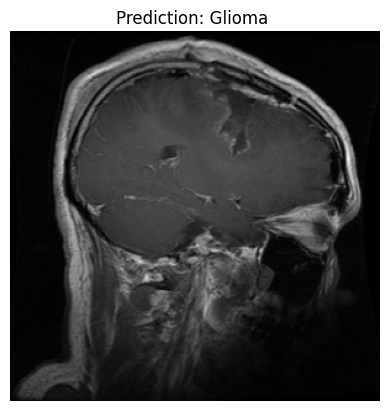

⚠️ Tumor Detected: Glioma 


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification – Colab Runtime Version
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -----------------------------
# ⚙️ CONFIG
# -----------------------------
IMG_SIZE = (300, 300)
CLASS_NAMES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']  # Adjust if your dataset differs
MODEL_PATH = "/content/best_model.keras"  # path to your trained model

# -----------------------------
# 🔹 LOAD TRAINED MODEL
# -----------------------------
print("✅ Loading trained model...")
try:
    model = load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print("❌ Error loading model:", e)

# -----------------------------
# 🔹 UPLOAD MRI IMAGE
# -----------------------------
print("\n📤 Please upload an MRI image...")
uploaded = files.upload()

for filename in uploaded.keys():
    IMAGE_PATH = filename
    print(f"✅ Uploaded file: {IMAGE_PATH}")

# -----------------------------
# 🔹 PREPROCESS FUNCTION
# -----------------------------
def preprocessing_function(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# -----------------------------
# 🔹 PREDICT FUNCTION
# -----------------------------
def predict_tumor(model, image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("❌ Could not read the uploaded image. Please upload a valid image.")

    proc_img = preprocessing_function(img)
    input_tensor = np.expand_dims(proc_img, axis=0)

    preds = model.predict(input_tensor)
    confidence = float(np.max(preds) * 100)
    pred_class = CLASS_NAMES[np.argmax(preds)]

    return pred_class, confidence, proc_img

# -----------------------------
# 🔹 RUN PREDICTION
# -----------------------------
pred_class, confidence, disp_img = predict_tumor(model, IMAGE_PATH)

# -----------------------------
# 🔹 DISPLAY RESULTS
# -----------------------------
plt.imshow(disp_img)
plt.axis('off')
plt.title(f"Prediction: {pred_class} ")
plt.show()

if pred_class.lower() == "no tumor":
    print(f"✅ No Brain Tumor Detected — Confidence: {confidence:.2f}%")
else:
    print(f"⚠️ Tumor Detected: {pred_class} ")
